## Scale Numerical Features


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns in df_encoded, excluding the 'target' column
# The target column is currently of 'object' type in df_encoded.
# All other numerical columns (both original and those created by one-hot encoding for binary features) are int or float.

# First, exclude the 'target' column from the DataFrame for scaling
X = df_encoded.drop(columns=['target'])

# Identify numerical columns for scaling
# These are columns that were not one-hot encoded and are continuous numerical features
# We already have `numerical_for_outliers` from a previous step, which is a good candidate list
numerical_cols_to_scale = numerical_for_outliers

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the identified numerical features
X[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

# Re-assign the processed numerical columns back to df_encoded (if df_encoded was used as the base)
# However, since X was created as a copy, we will just use X moving forward as the preprocessed DataFrame
# For clarity, let's keep the name `df_processed` for the final DataFrame after all preprocessing steps.
df_processed = X.copy()
df_processed['target'] = df_encoded['target']

print("Descriptive statistics for scaled numerical columns:")
print(df_processed[numerical_cols_to_scale].describe())

Descriptive statistics for scaled numerical columns:
       Previous qualification (grade)  Admission grade  \
count                    4.424000e+03     4.424000e+03   
mean                     2.062244e-15    -6.279887e-16   
std                      1.000113e+00     1.000113e+00   
min                     -2.504356e+00    -1.968758e+00   
25%                     -5.817779e-01    -6.363429e-01   
50%                      4.113725e-02    -5.825810e-02   
75%                      5.717687e-01     5.550758e-01   
max                      2.878862e+00     2.813202e+00   

       Curricular units 1st sem (grade)  Curricular units 2nd sem (grade)  \
count                      4.424000e+03                      4.424000e+03   
mean                      -1.509743e-16                      1.220643e-16   
std                        1.000113e+00                      1.000113e+00   
min                       -2.199424e+00                     -1.965152e+00   
25%                        7.564871e-02

## Explore Relationships with Target Variable




Generating stacked bar charts for categorical features vs. target...


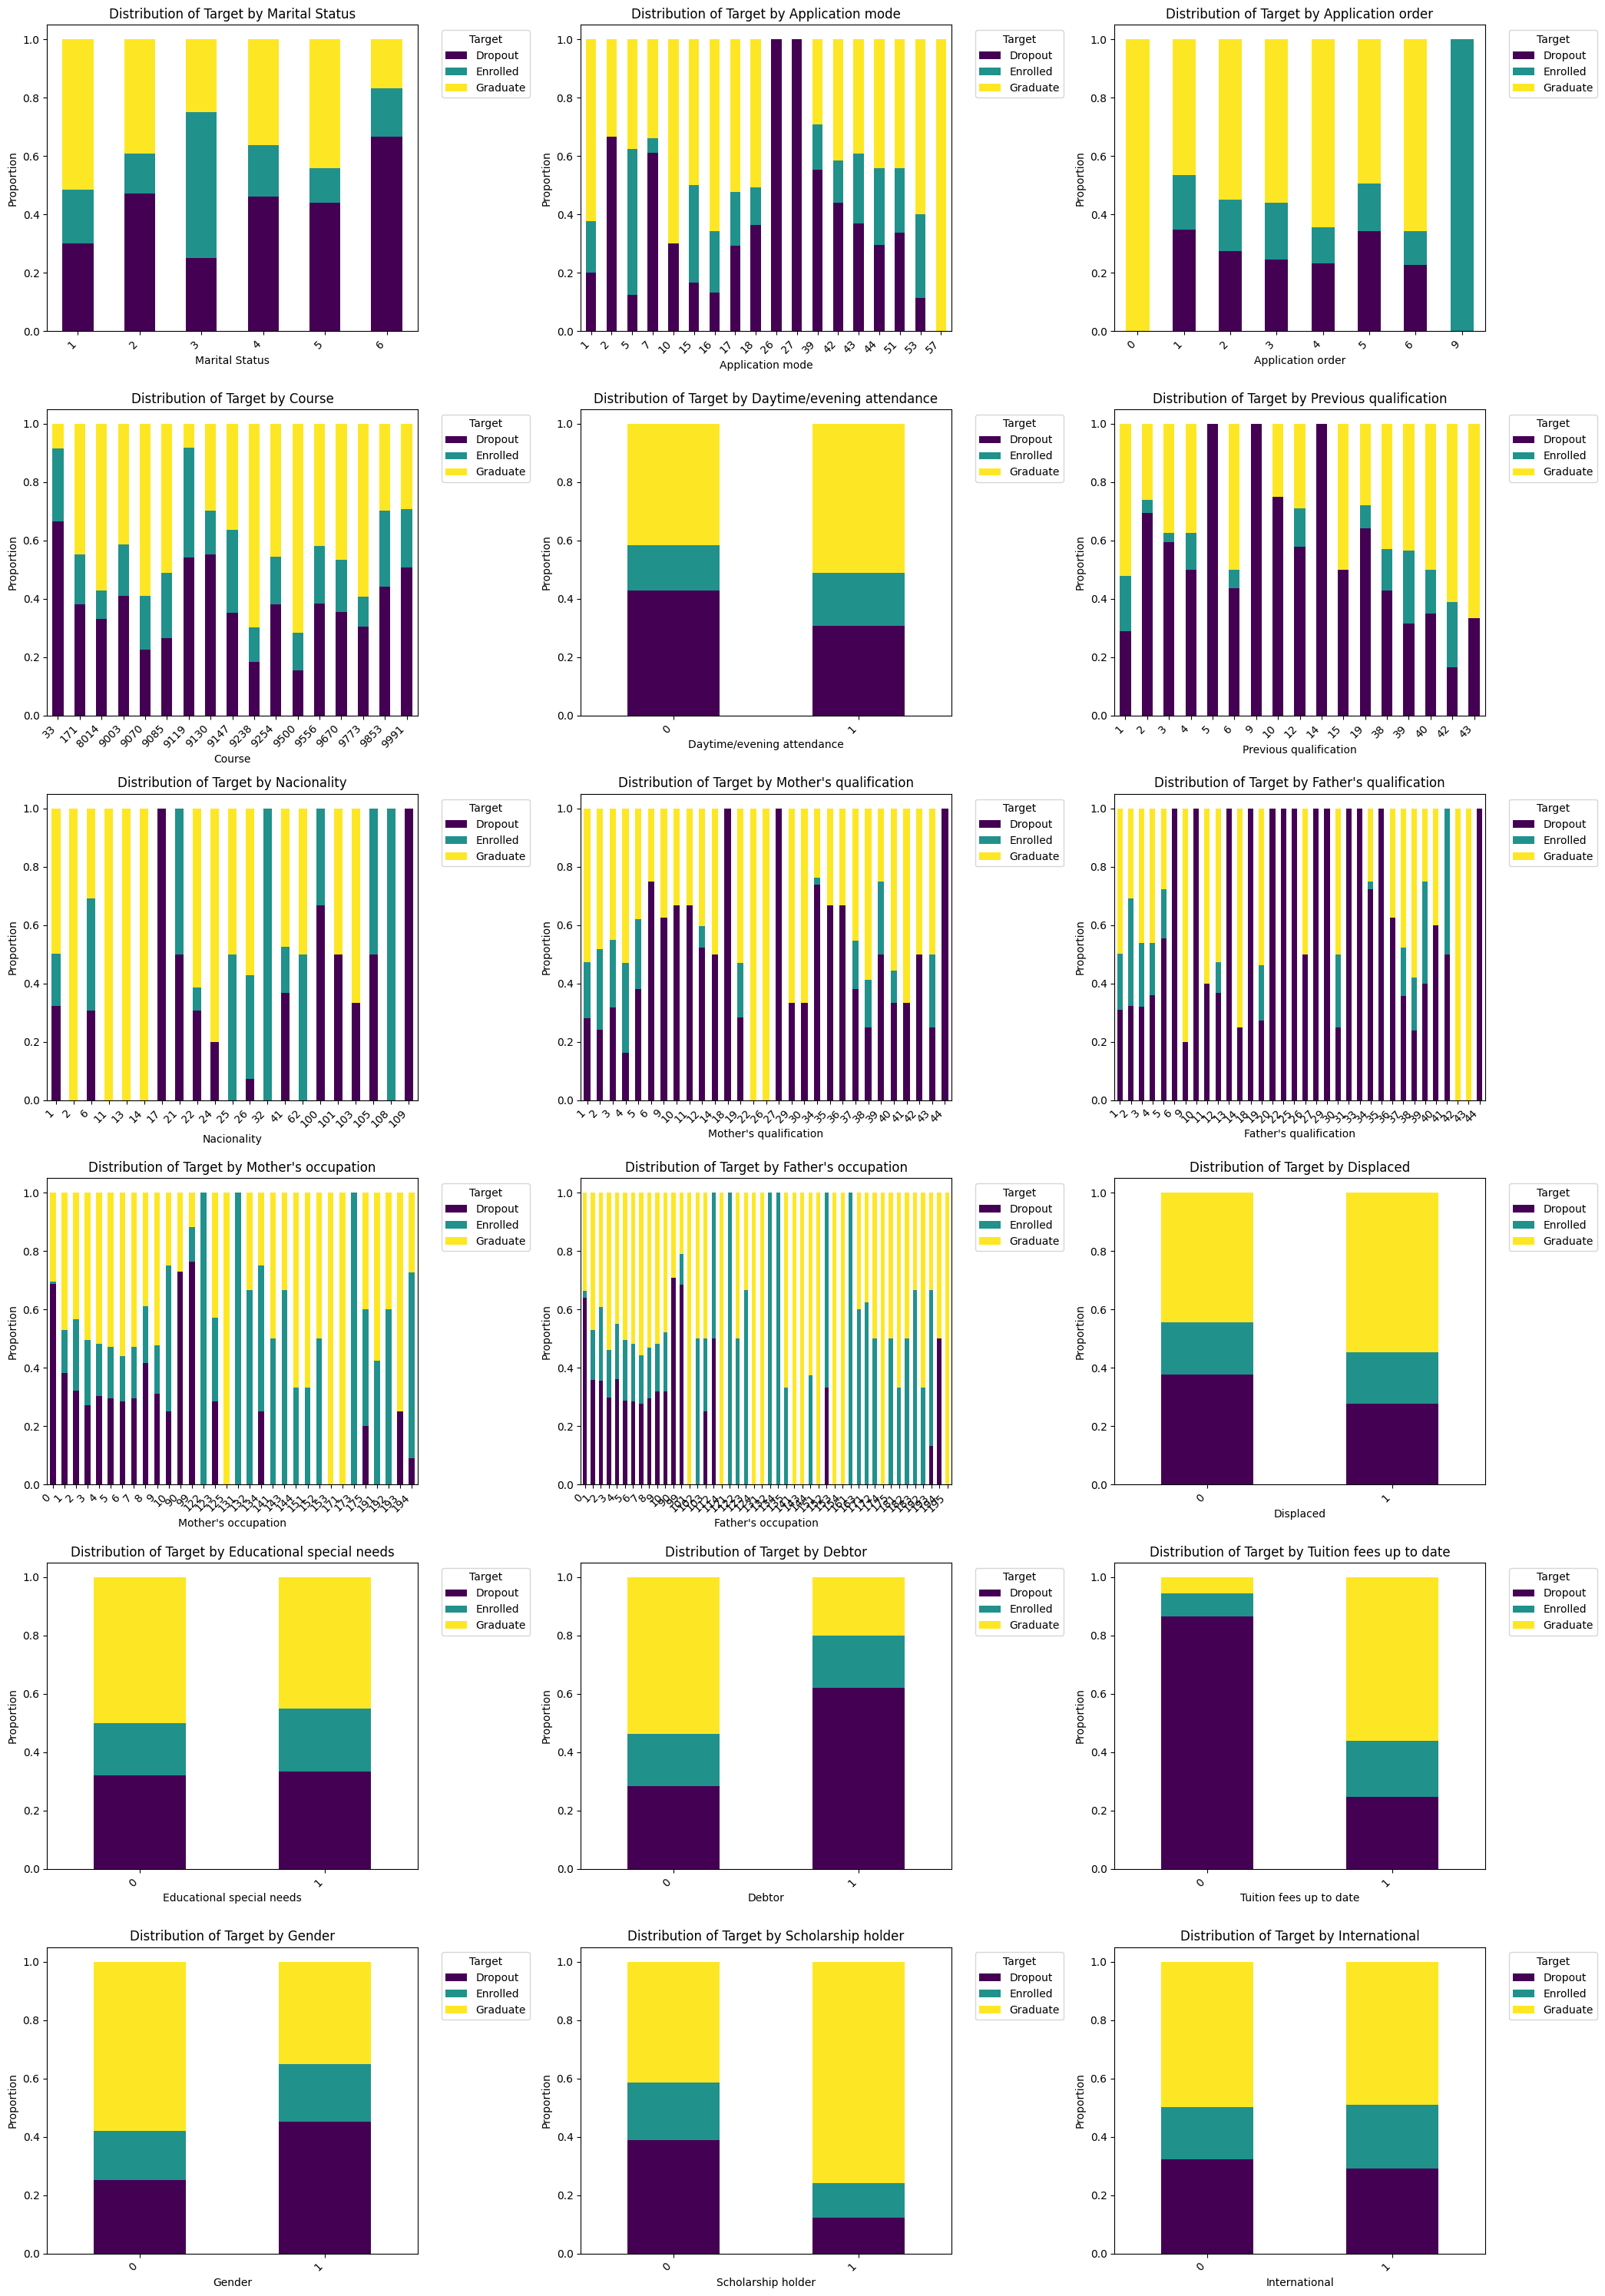

Stacked bar charts generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of original categorical features from the `categorical_features` variable
# The `df` DataFrame still holds the original categorical values

print("Generating stacked bar charts for categorical features vs. target...")

n_cols = 3  # Number of columns for the grid
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5))

for i, col in enumerate(categorical_features):
    plt.subplot(n_rows, n_cols, i + 1)

    # Create a cross-tabulation to get counts for each category and target class
    ct = pd.crosstab(df[col], df['target'], normalize='index') # normalize='index' for percentages

    ct.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'Distribution of Target by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.legend(title='Target', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Stacked bar charts generated successfully.")

Generating box plots for numerical features vs. target...


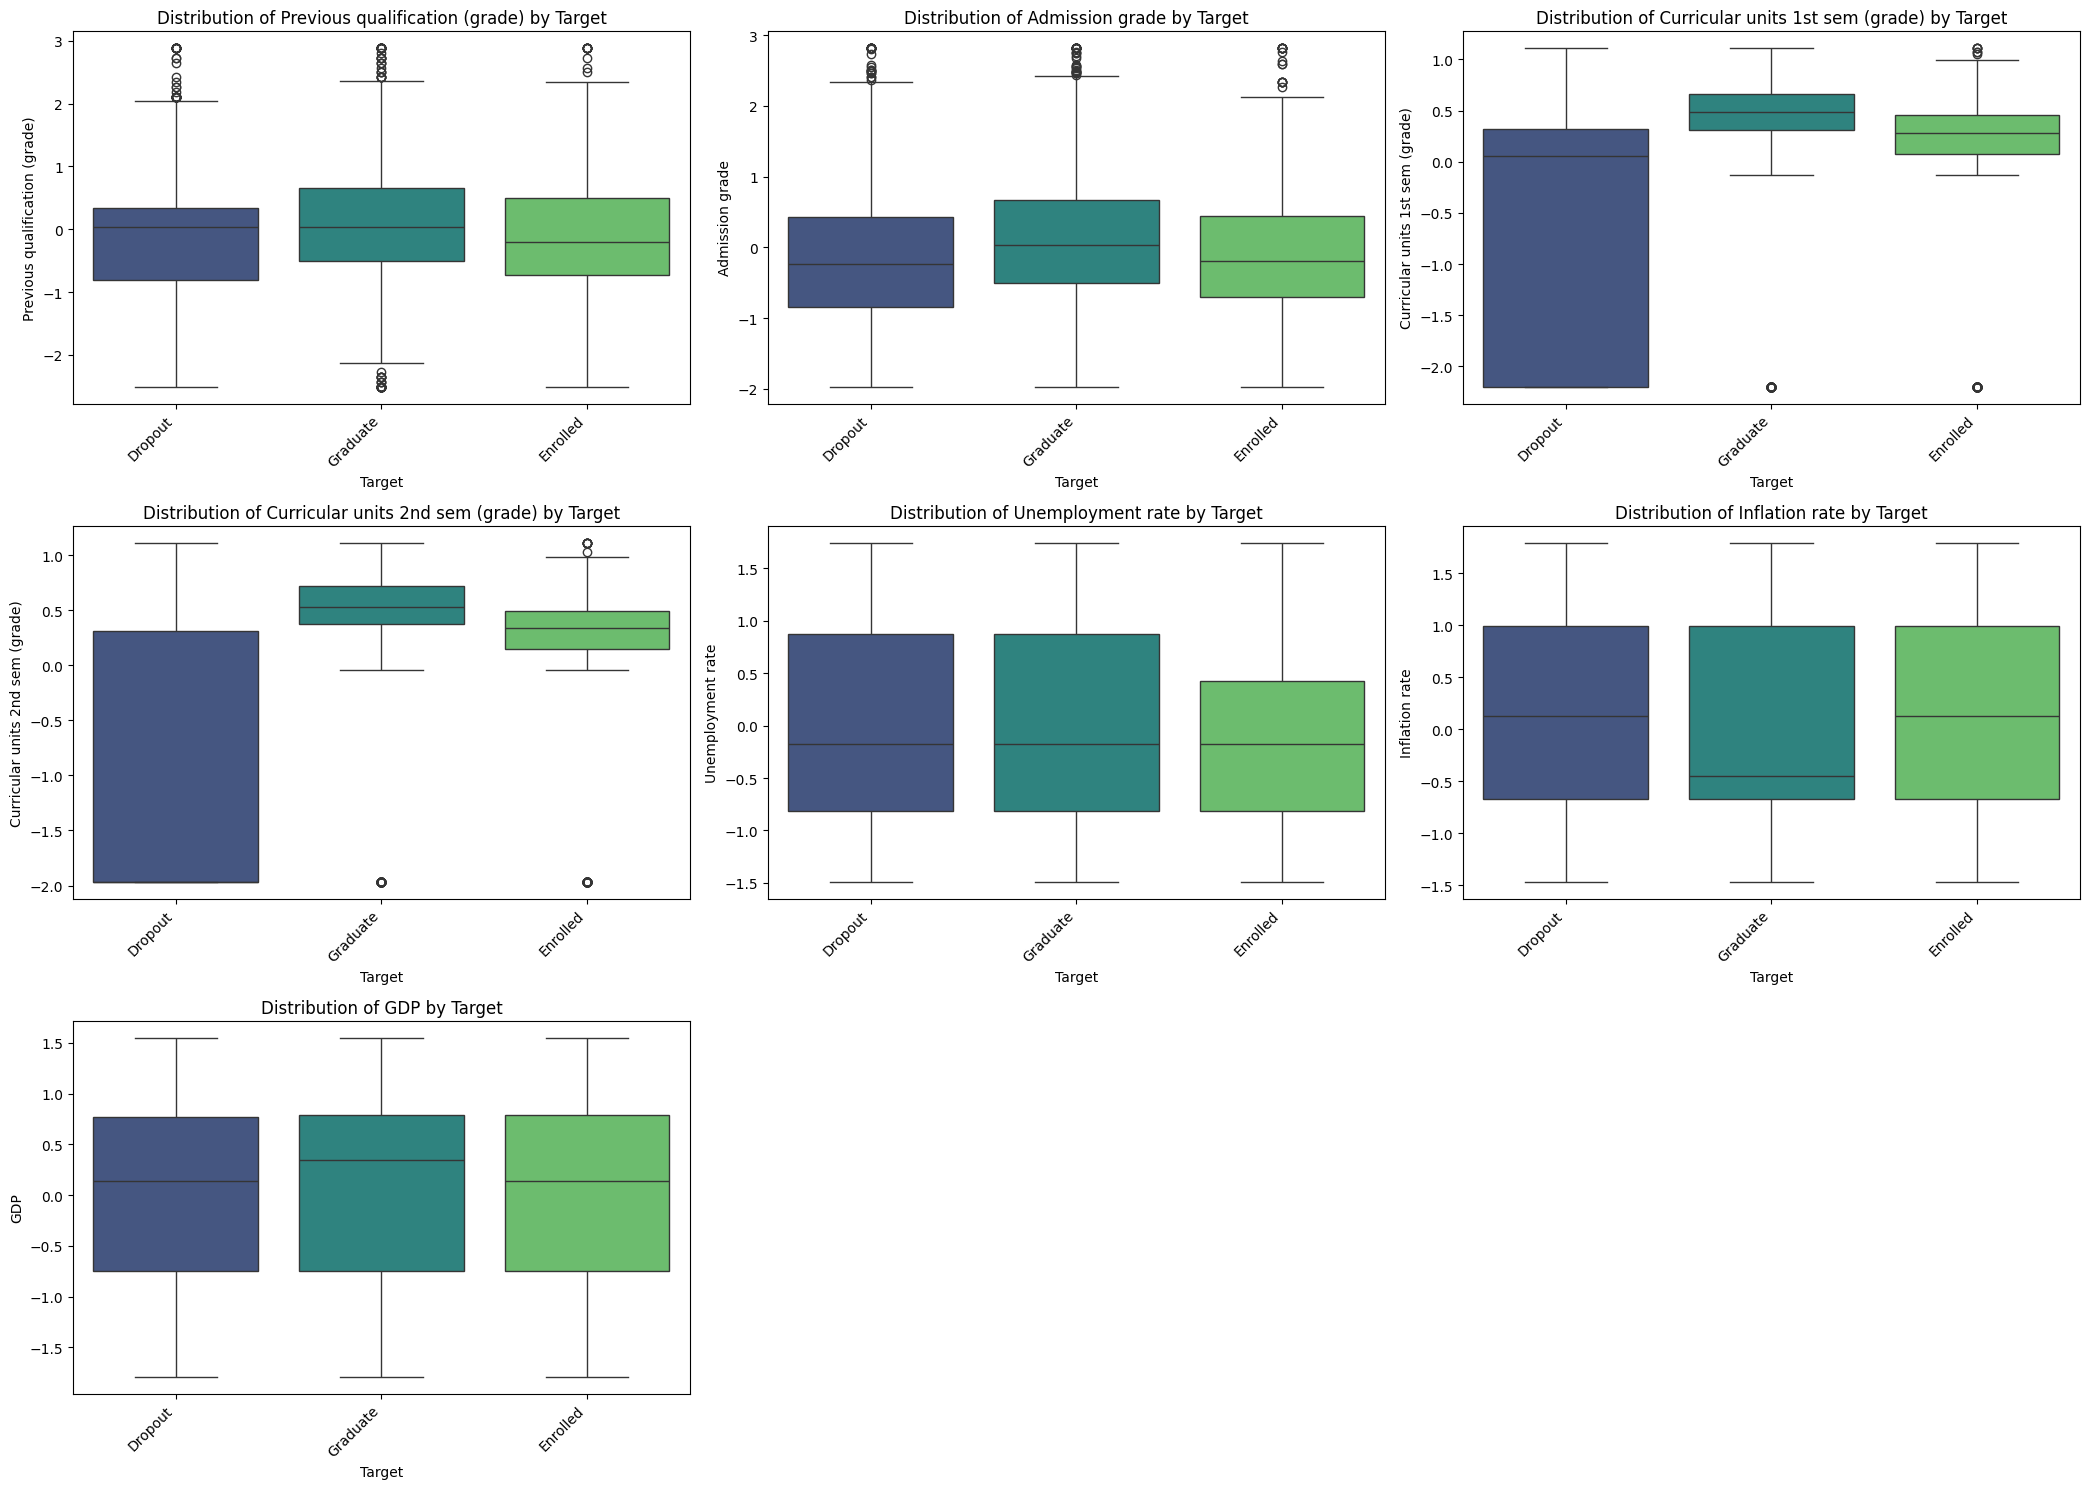

Box plots generated successfully.


In [ ]:
print("Generating box plots for numerical features vs. target...")

n_cols = 3  # Number of columns for the grid
n_rows = (len(numerical_for_outliers) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 7, n_rows * 5))

for i, col in enumerate(numerical_for_outliers):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_processed['target'], y=df_processed[col], hue=df_processed['target'], palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Target')
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("Box plots generated successfully.")

Correlation Heatmap

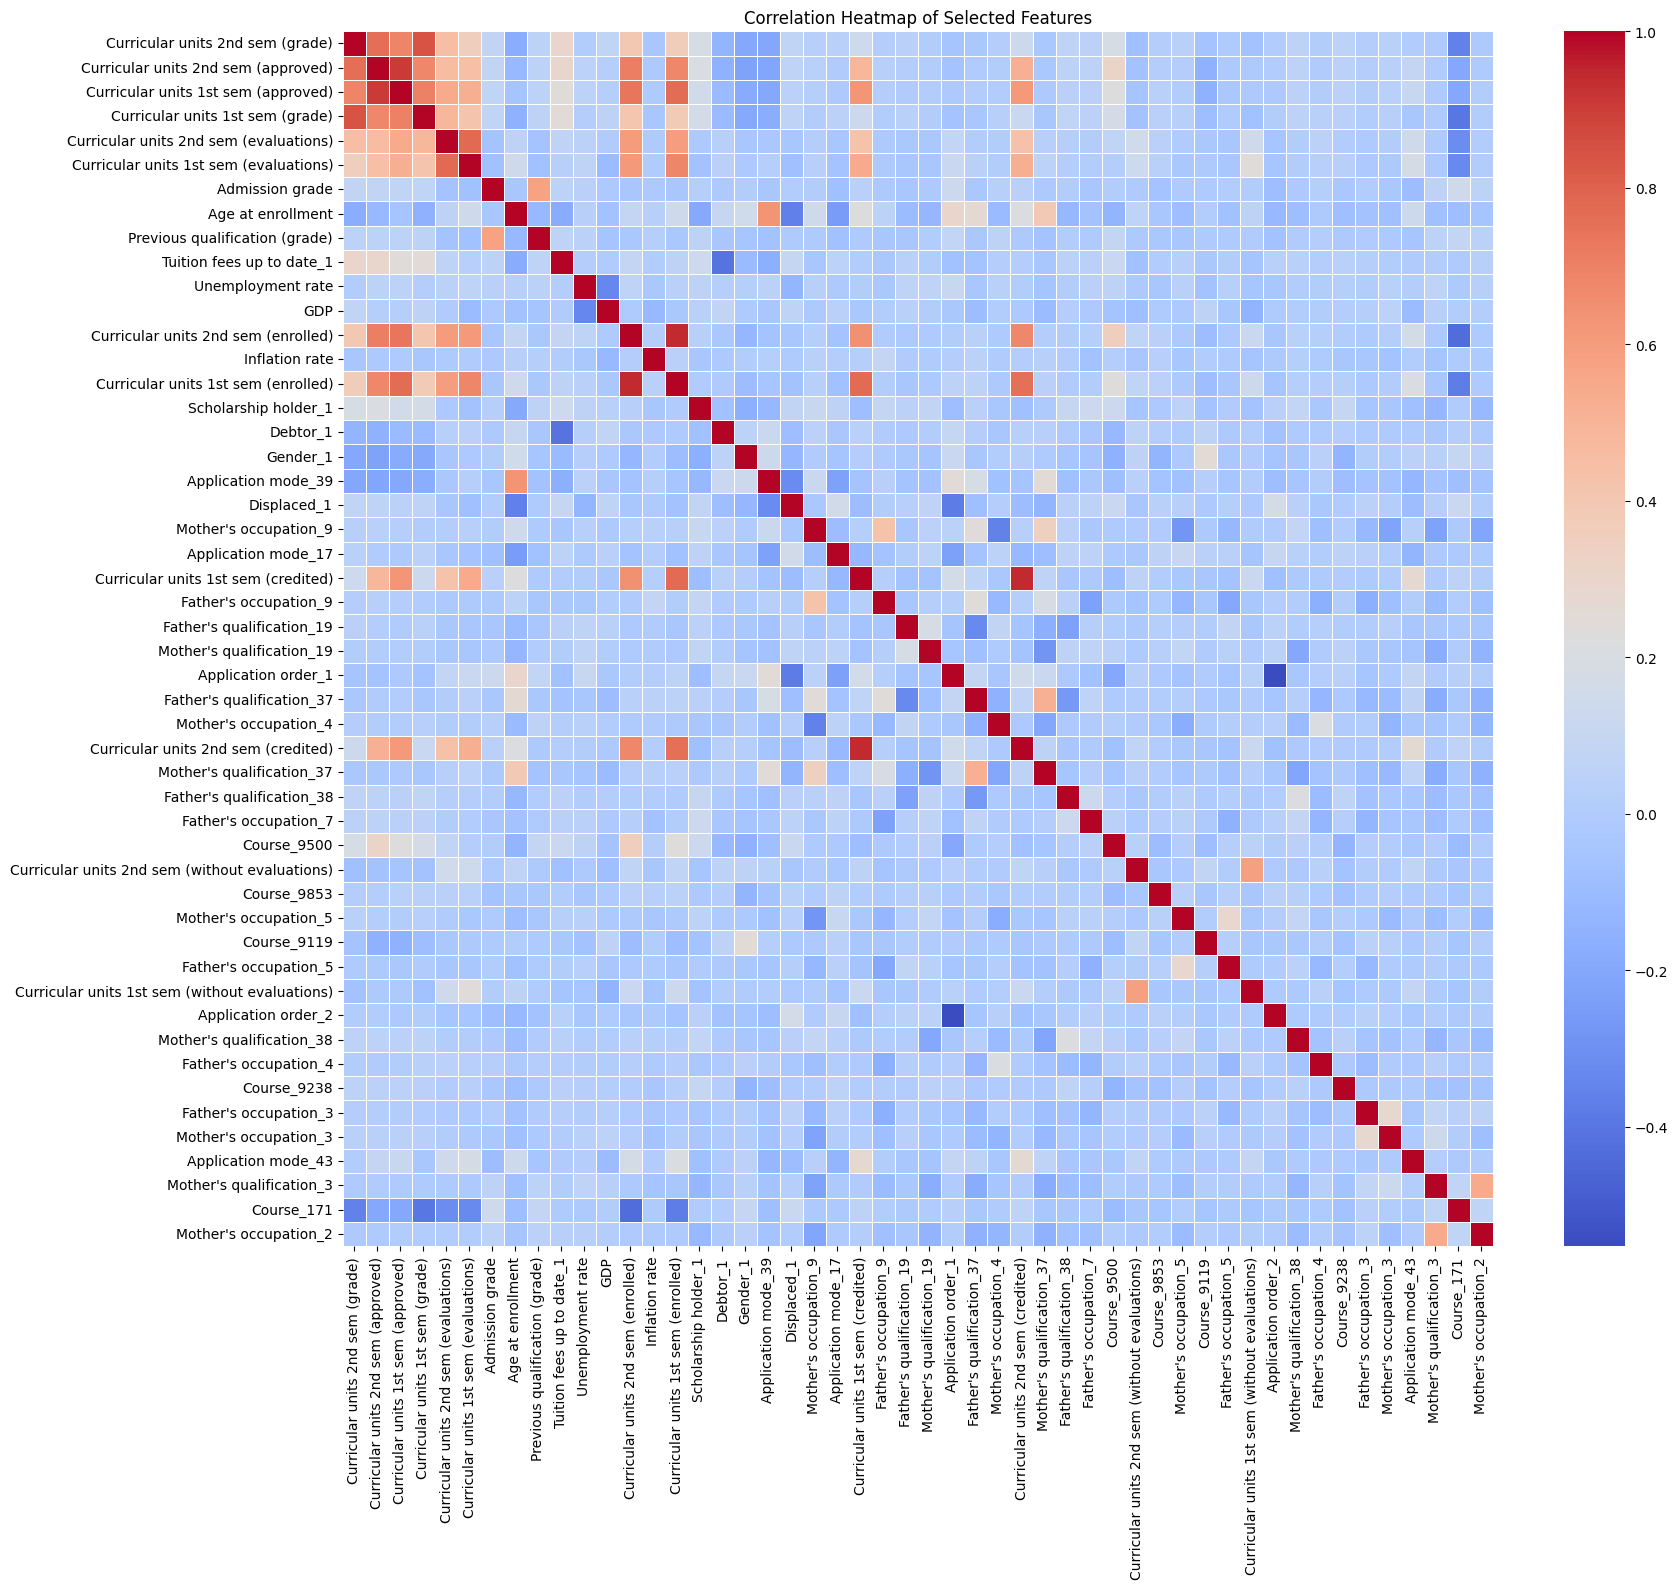

Correlation heatmap generated. Note: For better readability, a heatmap of a smaller subset of highly correlated or most important features could be generated if desired.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert boolean columns in X_selected to numeric (0s and 1s) for correlation calculation
X_selected_numeric = X_selected.copy()
for col in X_selected_numeric.select_dtypes(include='bool').columns:
    X_selected_numeric[col] = X_selected_numeric[col].astype(int)

# Calculate the correlation matrix
correlation_matrix = X_selected_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(18, 16)) # Adjust figure size for better readability with many features
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.show()

print("Correlation heatmap generated. Note: For better readability, a heatmap of a smaller subset of highly correlated or most important features could be generated if desired.")

## Calculate Feature Importance


Top 20 Most Important Features:
                                    feature  importance
13         Curricular units 2nd sem (grade)    0.103196
12      Curricular units 2nd sem (approved)    0.100789
6       Curricular units 1st sem (approved)    0.084841
7          Curricular units 1st sem (grade)    0.053442
11   Curricular units 2nd sem (evaluations)    0.037409
5    Curricular units 1st sem (evaluations)    0.037354
1                           Admission grade    0.035606
2                         Age at enrollment    0.035546
0            Previous qualification (grade)    0.032704
240               Tuition fees up to date_1    0.029360
15                        Unemployment rate    0.021571
17                                      GDP    0.021052
10      Curricular units 2nd sem (enrolled)    0.020730
16                           Inflation rate    0.019768
4       Curricular units 1st sem (enrolled)    0.018603
242                    Scholarship holder_1    0.017572
239             

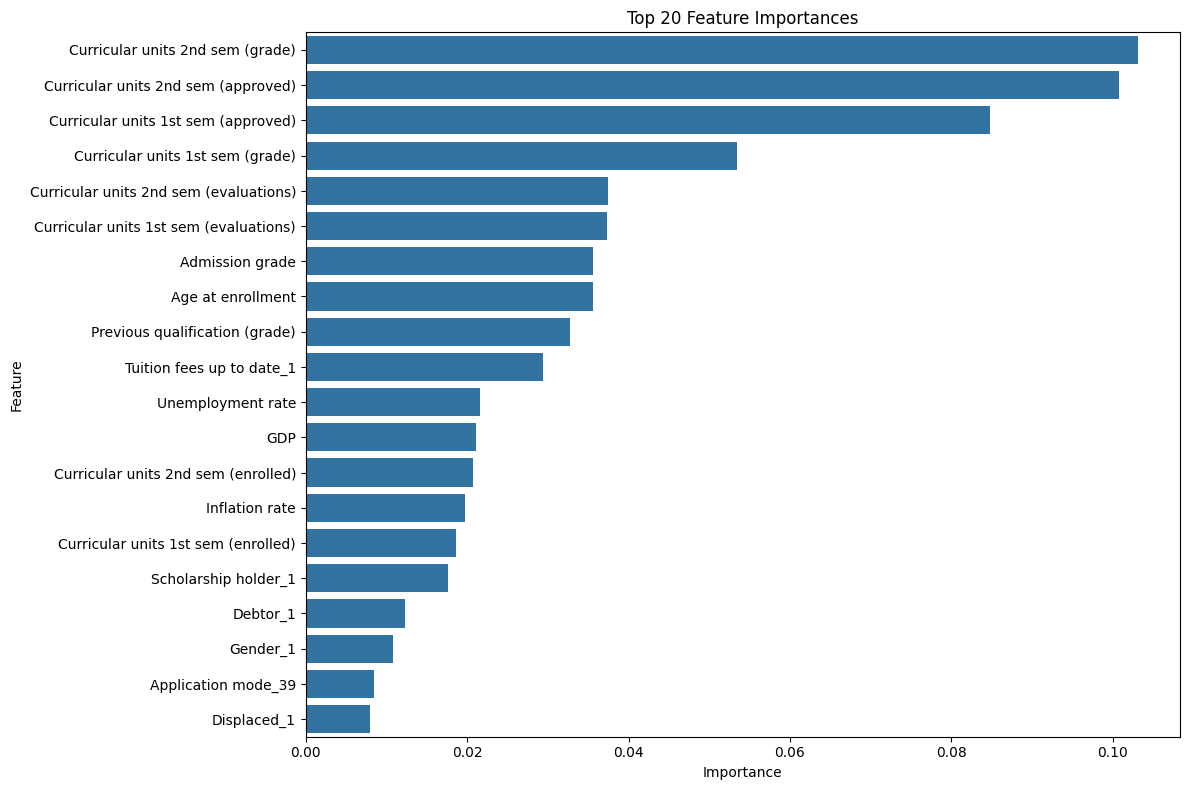

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df_processed.drop('target', axis=1)
y = df_processed['target']

# Encode the target variable numerically
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Initialize and train RandomForestClassifier
# Using a fixed random_state for reproducibility
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y_encoded)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importances.head(20))

# Visualize top N important features
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(20))
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Perform Feature Selection


In [ ]:
n_top_features = 50

top_features = feature_importances.head(n_top_features)['feature'].tolist()

X_selected = X[top_features]

print(f"Number of selected features: {len(top_features)}")
print("Selected features:")
for feature in top_features:
    print(f"- {feature}")

print("\nFirst 5 rows of X_selected:")
print(X_selected.head())

Number of selected features: 50
Selected features:
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (approved)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 2nd sem (evaluations)
- Curricular units 1st sem (evaluations)
- Admission grade
- Age at enrollment
- Previous qualification (grade)
- Tuition fees up to date_1
- Unemployment rate
- GDP
- Curricular units 2nd sem (enrolled)
- Inflation rate
- Curricular units 1st sem (enrolled)
- Scholarship holder_1
- Debtor_1
- Gender_1
- Application mode_39
- Displaced_1
- Mother's occupation_9
- Application mode_17
- Curricular units 1st sem (credited)
- Father's occupation_9
- Father's qualification_19
- Mother's qualification_19
- Application order_1
- Father's qualification_37
- Mother's occupation_4
- Curricular units 2nd sem (credited)
- Mother's qualification_37
- Father's qualification_38
- Father's occupation_7
- Course_9500
- Curricular units 2nd sem (without evaluations)
- C

## Apply Dimensionality Reduction (PCA)



In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA without specifying n_components to retain all principal components
pca = PCA()

# Fit PCA to the selected features and transform the data
X_pca = pca.fit_transform(X_selected)

print(f"Shape of data after PCA: {X_pca.shape}")

Shape of data after PCA: (4424, 50)


Explained variance ratio of each principal component:
[4.26728282e-01 3.37226979e-01 7.84212167e-02 3.90906529e-02
 2.30958829e-02 1.55106015e-02 1.09036570e-02 8.98321027e-03
 7.34913845e-03 6.43331707e-03 5.43382110e-03 4.18260867e-03
 2.95197968e-03 2.84324431e-03 2.56906428e-03 1.96947061e-03
 1.85330870e-03 1.68360821e-03 1.58070913e-03 1.46741216e-03
 1.36517256e-03 1.27435538e-03 1.18846234e-03 1.15228568e-03
 1.10804772e-03 1.01817543e-03 9.97036382e-04 9.57607755e-04
 8.90483547e-04 8.78734760e-04 8.44032922e-04 7.69312305e-04
 7.59526980e-04 7.01557843e-04 6.21423261e-04 5.94932098e-04
 5.87439109e-04 4.79559954e-04 4.53806591e-04 4.31792445e-04
 4.04905652e-04 3.85896737e-04 3.32853565e-04 3.26303048e-04
 2.55177824e-04 2.48082519e-04 2.23469830e-04 2.15487172e-04
 1.46507226e-04 1.09406161e-04]

Cumulative explained variance:
[0.42672828 0.76395526 0.84237648 0.88146713 0.90456301 0.92007362
 0.93097727 0.93996048 0.94730962 0.95374294 0.95917676 0.96335937
 0.96631135 0.96

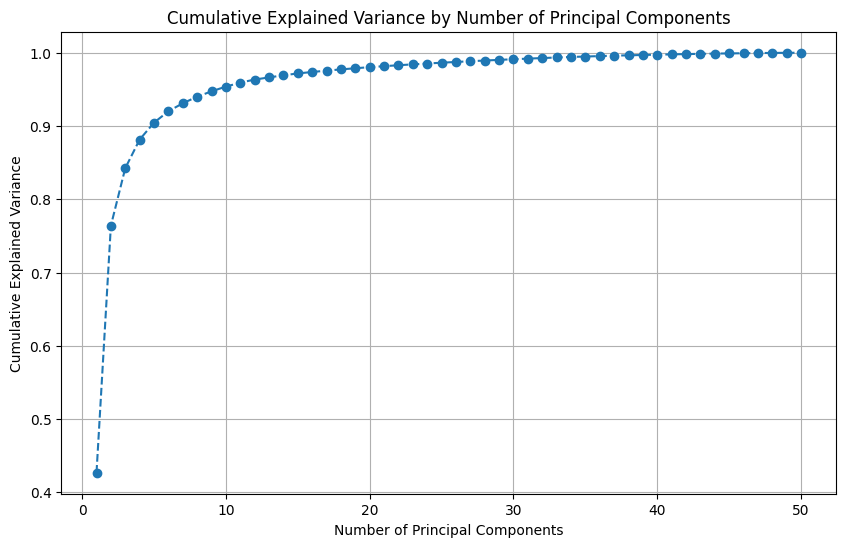

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate the cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio of each principal component:")
print(explained_variance_ratio)

print("\nCumulative explained variance:")
print(cumulative_explained_variance)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()